## <span style="color:#white; font-weight:bold;"> Sessões de BAA - Março de 2026:</span>

<img src="https://images.wallpapersden.com/image/download/phone-office-desk_Z2hnaGeUmZqaraWkpJRpZ21trWdtaW0.jpg"
     width="700"
     style="display: block; margin: 0 auto;" />

### <span style="color:#FFDE42; font-weight:bold;"> *CALL ME MAYBE?* ☎️ </span>

#### <span style="color:#white; font-weight:bold;"> Desafio </span> 🧩

És consultor na NTT DATA e foste alocado a um projeto num dos maiores bancos de retalho em Portugal.

Os depósitos a prazo representam uma importante fonte de receita para o banco. Na divulgação deste produto, uma das abordagens mais eficazes é o marketing telefónico. No entanto, envolve também um grande volume de contactos, tornando o processo exigente a nível operacional.

Como parte da equipa de data analytics, o teu objetivo é analisar dados históricos de contactos telefónicos para detetar padrões de comportamento e os fatores com maior impacto no sucesso de uma campanha, permitindo identificar clientes-alvo.

Esta análise permitirá ao banco tomar decisões mais informadas com base em dados, otimizando a seleção dos  contactos a fazer, aumentado a taxa de conversão e ainda a satisfação do cliente.

> 🎯 **Objetivo:** Identificar a lista de clientes a contactar para a venda de depósitos a prazo, estimando a probabilidade de cada um subscrever o produto e ordenando por prioridade

#### <span style="color:#white; font-weight:bold;"> Dados disponíveis </span> 📋

Para a análise, foram disponibilizados dados de cliente e de milhares de contactos telefónicos, entre Maio de 2008 a Novembro de 2010, correspondendo a 45 mil linhas e 17 colunas.

| **Variável** | **Descrição** | **Exemplo** |
| :--- | :--- | :--- |
| age | idade do cliente, em anos | 30 |
| job | profissão do cliente | self-employed |
| maritial | estado civil do cliente | married |
| education | habilitações literárias do cliente | primary |
| default | se o cliente tem crédito em incumprimento | yes |
| balance | saldo médio anual da conta, em euros | 1350 |
| housing | se o cliente tem crédito à habitação | yes |
| loan | se o cliente tem crédito pessoal | no |
| contact | tipo de comunicação | cellular |
| day | dia do mês do último contacto | 16 |
| month | mês do último contacto | feb |
| duration | duração da última chamada, em segundos | 220 |
| campaign | número de contactos durante a campanha | 1 |
| pdays | número de dias desde o último contacto (-1 se nunca) | 330 |
| previous | número total de contactos antes da campanha | 4 |
| poutcome | resultado da última campanha | failure |
| y | se o cliente subscreveu um depósito a prazo | no |

#### <span style="color:#white; font-weight:bold;"> *Setup* </span> ⚙️

In [4]:
# Setup
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)


#### <span style="color:#white; font-weight:bold;"> Ingestão dos dados </span> 📦

In [5]:
# load the data
print("Loading data...")
try:
    df = pd.read_csv("data.csv", sep=";")
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: File not found.")

# print the first 3 rows
df.head(3)

Loading data...
Data loaded successfully.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


# 3. Data Understanding

In [14]:
# Configuration
RANDOM_SEED = 42
DATA_PATH = "data.csv" 
TARGET_COL = "y"
ID_COL = None  # Example: "client_id"
CSV_SEPARATOR = ";"  # Change to "," if needed
TEST_SIZE = 0.25

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

In [22]:
print(f"\nDuplicate rows: {df.duplicated().sum()}")


numeric_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns



print("\nNumeric descriptive statistics:")
numeric_summary = df[numeric_cols].agg(
    ["count", "mean", "std", "min", "median", "max"]
).T

display(numeric_summary)


print("\nCategorical descriptive statistics:")

categorical_summary = pd.DataFrame({
    "count": df[categorical_cols].count(),
    "unique": df[categorical_cols].nunique(),
    "top": df[categorical_cols].mode().iloc[0],
    "freq": df[categorical_cols].apply(lambda x: x.value_counts().iloc[0] if not x.value_counts().empty else None)
})

display(categorical_summary)


Duplicate rows: 0

Numeric descriptive statistics:


,count,mean,std,min,median,max
age,45211.0,40.936210,10.618762,18.0,39.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,448.0,102127.0
day,45211.0,15.806419,8.322476,1.0,16.0,31.0
duration,45211.0,258.163080,257.527812,0.0,180.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,2.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,275.0



Categorical descriptive statistics:


,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


,count
y,
no,39922
yes,5289


,percentage
y,
no,88.3
yes,11.7


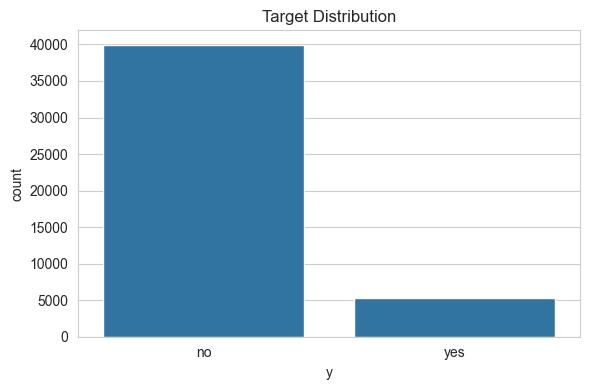

In [16]:
# Target distribution
target_counts = df[TARGET_COL].value_counts(dropna=False)
target_ratio = df[TARGET_COL].value_counts(normalize=True, dropna=False) * 100

display(target_counts.to_frame("count"))
display(target_ratio.round(2).to_frame("percentage"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COL)
plt.title("Target Distribution")
plt.tight_layout()
plt.show()

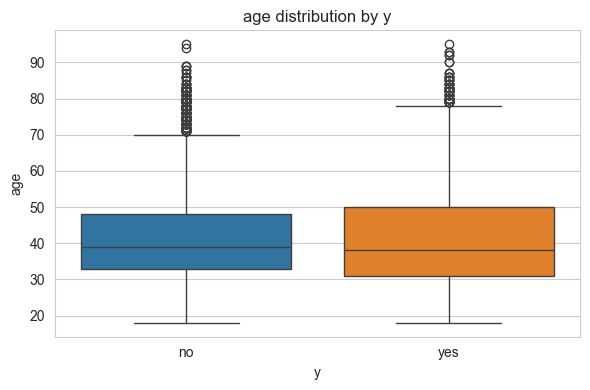

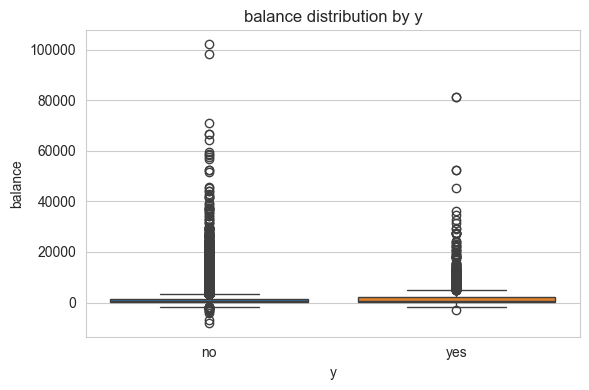

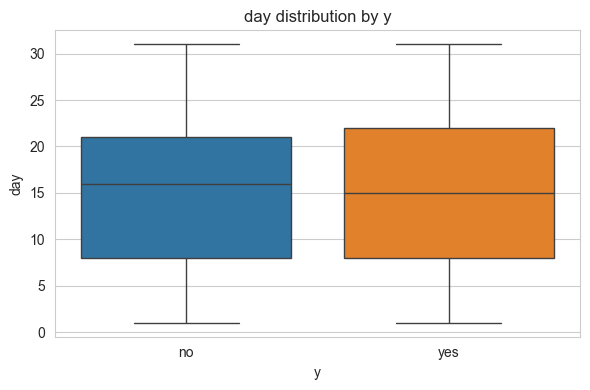

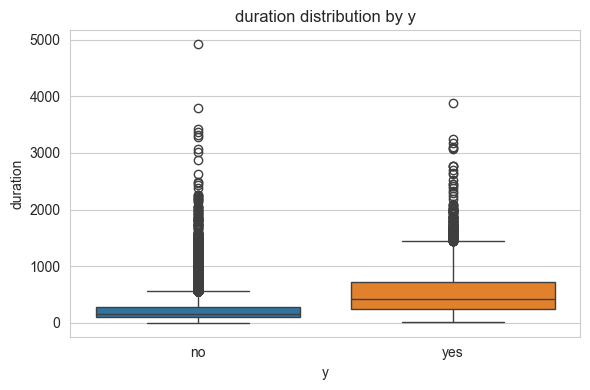

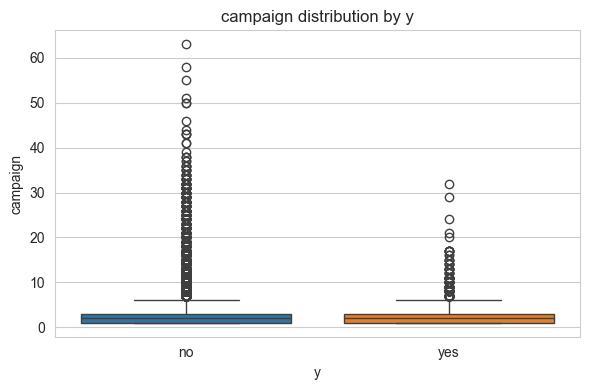

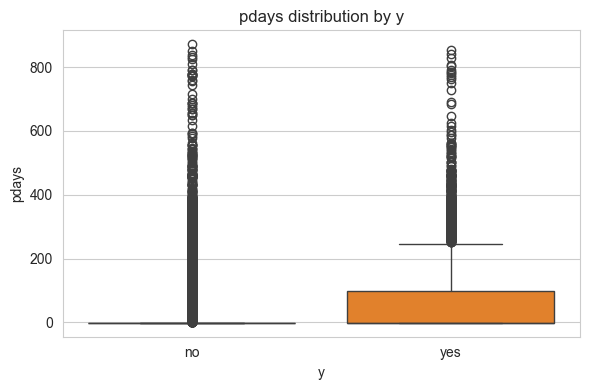

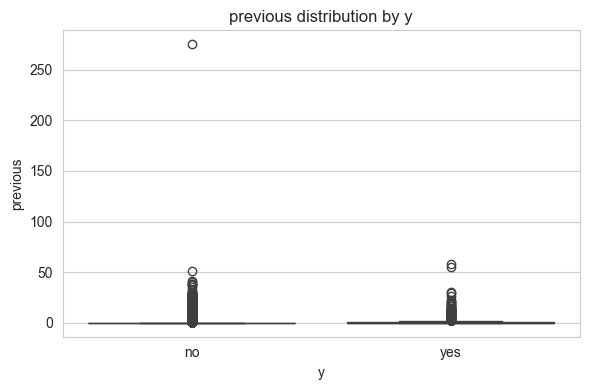

In [23]:
numeric_cols = df.select_dtypes(include=["number"]).columns

# Remove target if numeric
numeric_cols = [col for col in numeric_cols if col != TARGET_COL]

for col in numeric_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        data=df,
        x=TARGET_COL,
        y=col,
        hue=TARGET_COL,
        dodge=False,
        legend=False
    )
    
    plt.title(f"{col} distribution by {TARGET_COL}")
    plt.tight_layout()
    plt.show()

Numeric columns: 7
Categorical columns: 9


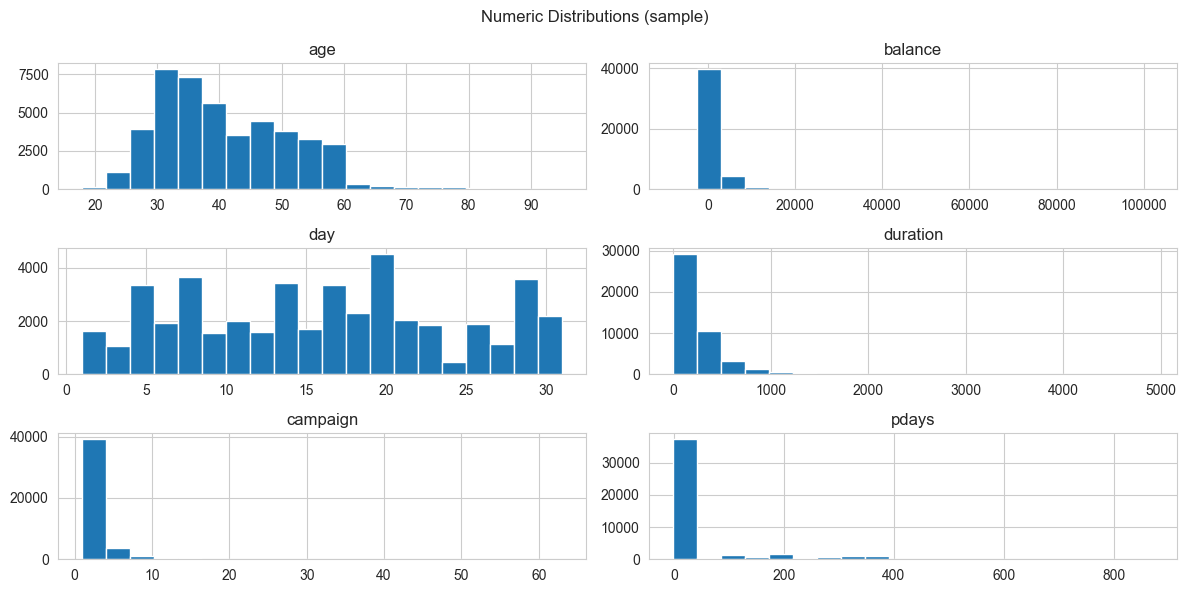

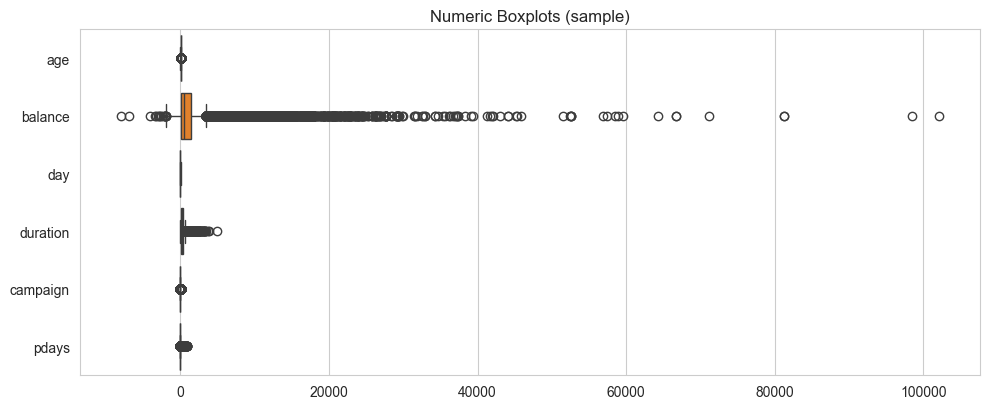

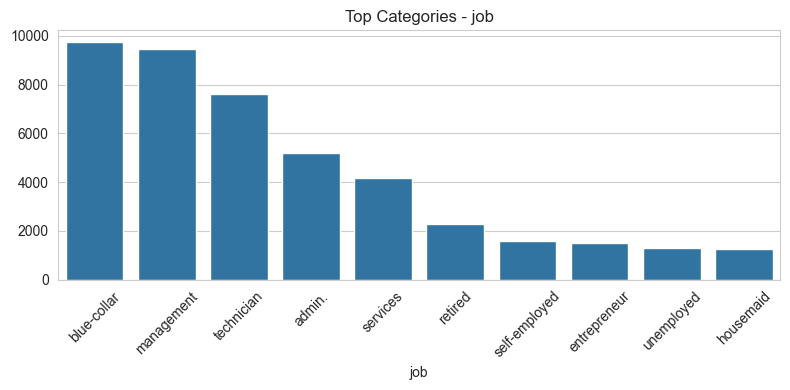

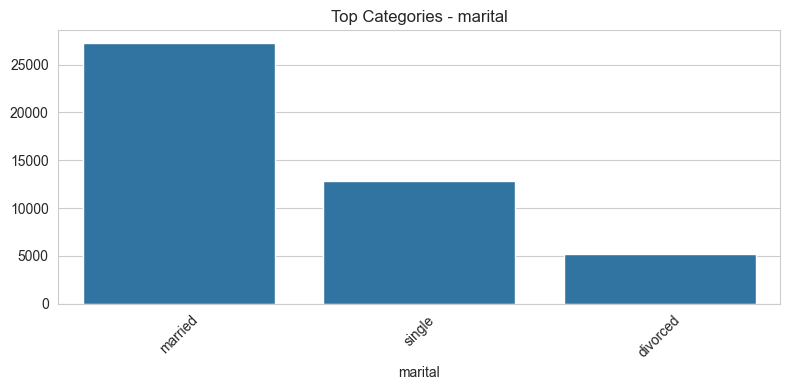

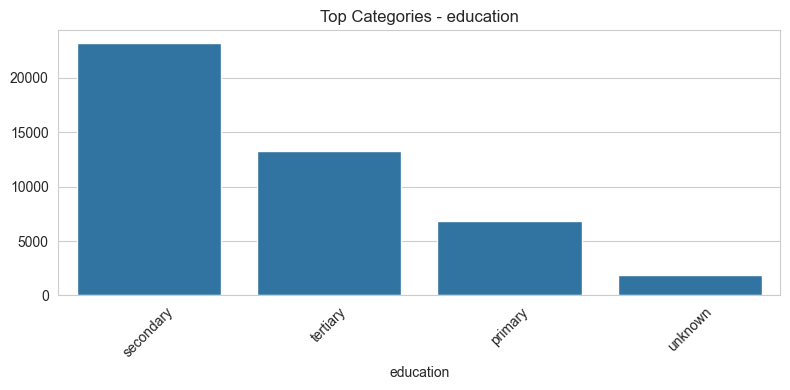

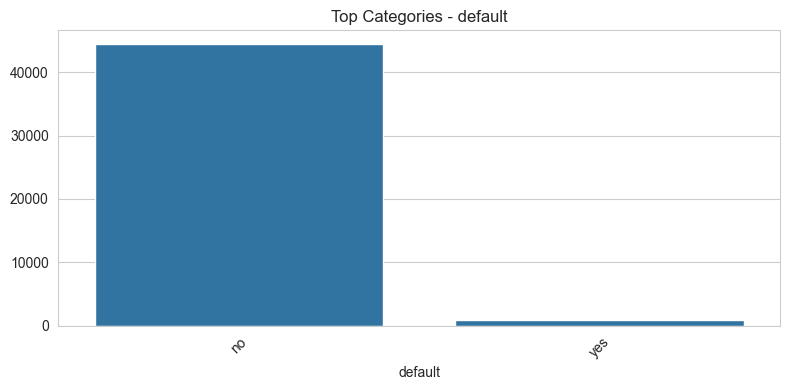

In [17]:
# Simple exploration of numeric and categorical variables
feature_cols = [c for c in df.columns if c != TARGET_COL]
numeric_cols = df[feature_cols].select_dtypes(include=np.number).columns.tolist()
categorical_cols = df[feature_cols].select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

if numeric_cols:
    numeric_sample = numeric_cols[:6]
    df[numeric_sample].hist(figsize=(12, 6), bins=20)
    plt.suptitle("Numeric Distributions (sample)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, max(4, len(numeric_sample) * 0.7)))
    sns.boxplot(data=df[numeric_sample], orient="h")
    plt.title("Numeric Boxplots (sample)")
    plt.tight_layout()
    plt.show()

for col in categorical_cols[:4]:
    plt.figure(figsize=(8, 4))
    top_values = df[col].value_counts().head(10)
    sns.barplot(x=top_values.index, y=top_values.values)
    plt.title(f"Top Categories - {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 4. Data Preparation

In [18]:
# Define features and target
X = df.drop(columns=[TARGET_COL]).copy()
y_raw = df[TARGET_COL].copy()

# Convert target to 0/1 (expects yes/no by default)
if y_raw.dtype == "O":
    y = y_raw.astype(str).str.lower().map({"yes": 1, "no": 0})
    if y.isna().any():
        unique_values = sorted(y_raw.dropna().astype(str).unique())
        if len(unique_values) != 2:
            raise ValueError("Target is not binary. Please review TARGET_COL.")
        mapping = {unique_values[0]: 0, unique_values[1]: 1}
        y = y_raw.astype(str).map(mapping)
else:
    y = y_raw.astype(int)

if y.isna().any():
    raise ValueError("Target contains unmapped values. Please review target mapping.")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

# Identify numeric and categorical columns
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Preprocessing pipelines
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Train shape: (33908, 16)
Test shape: (11303, 16)
Numeric features: 7
Categorical features: 9


# 5. Modeling

In [9]:
# Baseline and candidate models
models = {
    "Baseline_Dummy": DummyClassifier(strategy="prior", random_state=RANDOM_SEED),
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "Decision_Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_SEED),
    "Random_Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
}

results = []
fitted_models = {}

for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_prob),
        }
    )

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Random_Forest,0.907193,0.672131,0.403177,0.504019,0.928590
1,Logistic_Regression,0.901354,0.643154,0.351740,0.454768,0.906140
2,Decision_Tree,0.900646,0.618312,0.393343,0.480814,0.843759
3,Baseline_Dummy,0.883040,0.000000,0.000000,0.000000,0.500000


# 6. Evaluation

Best model: Random_Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      9981
           1       0.67      0.40      0.50      1322

    accuracy                           0.91     11303
   macro avg       0.80      0.69      0.73     11303
weighted avg       0.90      0.91      0.90     11303



,metric,value
0,accuracy,0.907193
1,precision,0.672131
2,recall,0.403177
3,f1_score,0.504019
4,roc_auc,0.928590


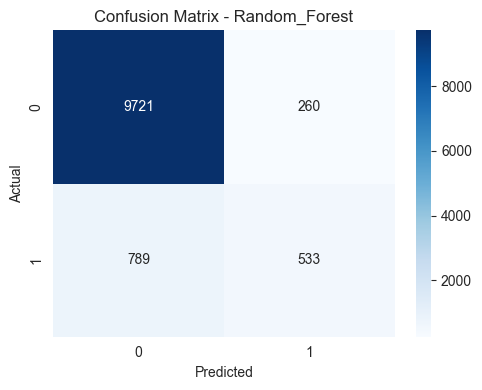

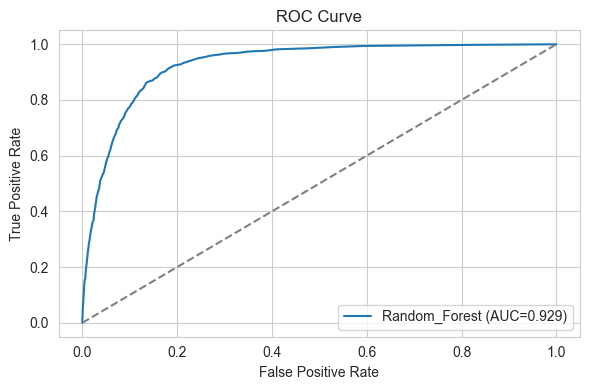

In [10]:
# Select best model by ROC-AUC
best_model_name = results_df.loc[0, "model"]
best_model = fitted_models[best_model_name]

print(f"Best model: {best_model_name}")

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

metrics_table = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1_score", "roc_auc"],
        "value": [
            accuracy_score(y_test, y_pred_best),
            precision_score(y_test, y_pred_best, zero_division=0),
            recall_score(y_test, y_pred_best, zero_division=0),
            f1_score(y_test, y_pred_best, zero_division=0),
            roc_auc_score(y_test, y_prob_best),
        ],
    }
)
display(metrics_table)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_value = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Build ranked client list for contact priority
if ID_COL is not None and ID_COL in X_test.columns:
    client_ids = X_test[ID_COL].astype(str).values
else:
    client_ids = X_test.index.astype(str)

priority_list = pd.DataFrame(
    {
        "client_id": client_ids,
        "predicted_probability": y_prob_best,
        "predicted_class": (y_prob_best >= 0.50).astype(int),
    }
).sort_values("predicted_probability", ascending=False).reset_index(drop=True)

display(priority_list.head(20))

,client_id,predicted_probability,predicted_class
0,34047,0.916667,1
1,42986,0.916667,1
2,44540,0.910000,1
3,43033,0.903333,1
4,40590,0.900000,1
5,44029,0.890000,1
6,41742,0.890000,1
7,41963,0.886667,1
8,44560,0.883333,1
9,40628,0.880000,1


# 7. Final Recommendations

- **Best model chosen:** Use the top model by ROC-AUC from the comparison table.
- **Main business takeaway:** Predicted probabilities allow the bank to focus calls on higher-likelihood clients and reduce inefficient contacts.
- **Campaign usage:** Start by contacting the top-ranked clients first (e.g., top 10-20%), then expand by available team capacity.
- **Simple next steps:** calibrate decision threshold with business costs, validate on a future campaign period, and retrain regularly with new data.